In [ ]:
#Clasificación de imágenes del MINST usando una red de una capa y una red multicapas

In [30]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
#Tarea: Usar el conjunto de entrenamiento y validación MINTS para entrenar un modelo de una capa y una neurona usando la función activación 'softmax', una función de perdidad "sparse_categorical_crossentropy" y la metica 'accuracy'

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(np.shape(x_train))
print(np.shape(y_train))

print(np.shape(x_test))
print(np.shape(y_test))

11490434/11490434 [==============================] - 1s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


In [3]:
x_train=x_train/255
x_test=x_test/255

In [4]:
print(np.shape(x_train))

(60000, 28, 28)


In [5]:
x_train_flat = x_train.reshape(np.shape(x_train)[0],-1)
x_test_flat = x_test.reshape(np.shape(x_test)[0],-1)

np.shape(x_train)
np.shape(x_train_flat)

(60000, 784)

In [6]:
tf.keras.datasets.mnist.load_data?

Signature: tf.keras.datasets.mnist.load_data(path='mnist.npz')
Docstring:
Loads the MNIST dataset.

This is a dataset of 60,000 28x28 grayscale images of the 10 digits,
along with a test set of 10,000 images.
More info can be found at the
[MNIST homepage](http://yann.lecun.com/exdb/mnist/).

Args:
  path: path where to cache the dataset locally
    (relative to `~/.keras/datasets`).

Returns:
  Tuple of NumPy arrays: `(x_train, y_train), (x_test, y_test)`.

**x_train**: uint8 NumPy array of grayscale image data with shapes
  `(60000, 28, 28)`, containing the training data. Pixel values range
  from 0 to 255.

**y_train**: uint8 NumPy array of digit labels (integers in range 0-9)
  with shape `(60000,)` for the training data.

**x_test**: uint8 NumPy array of grayscale image data with shapes
  (10000, 28, 28), containing the test data. Pixel values range
  from 0 to 255.

**y_test**: uint8 NumPy array of digit labels (integers in range 0-9)
  with shape `(10000,)` for the test data.

Ex

Imagenes de entrenamiento



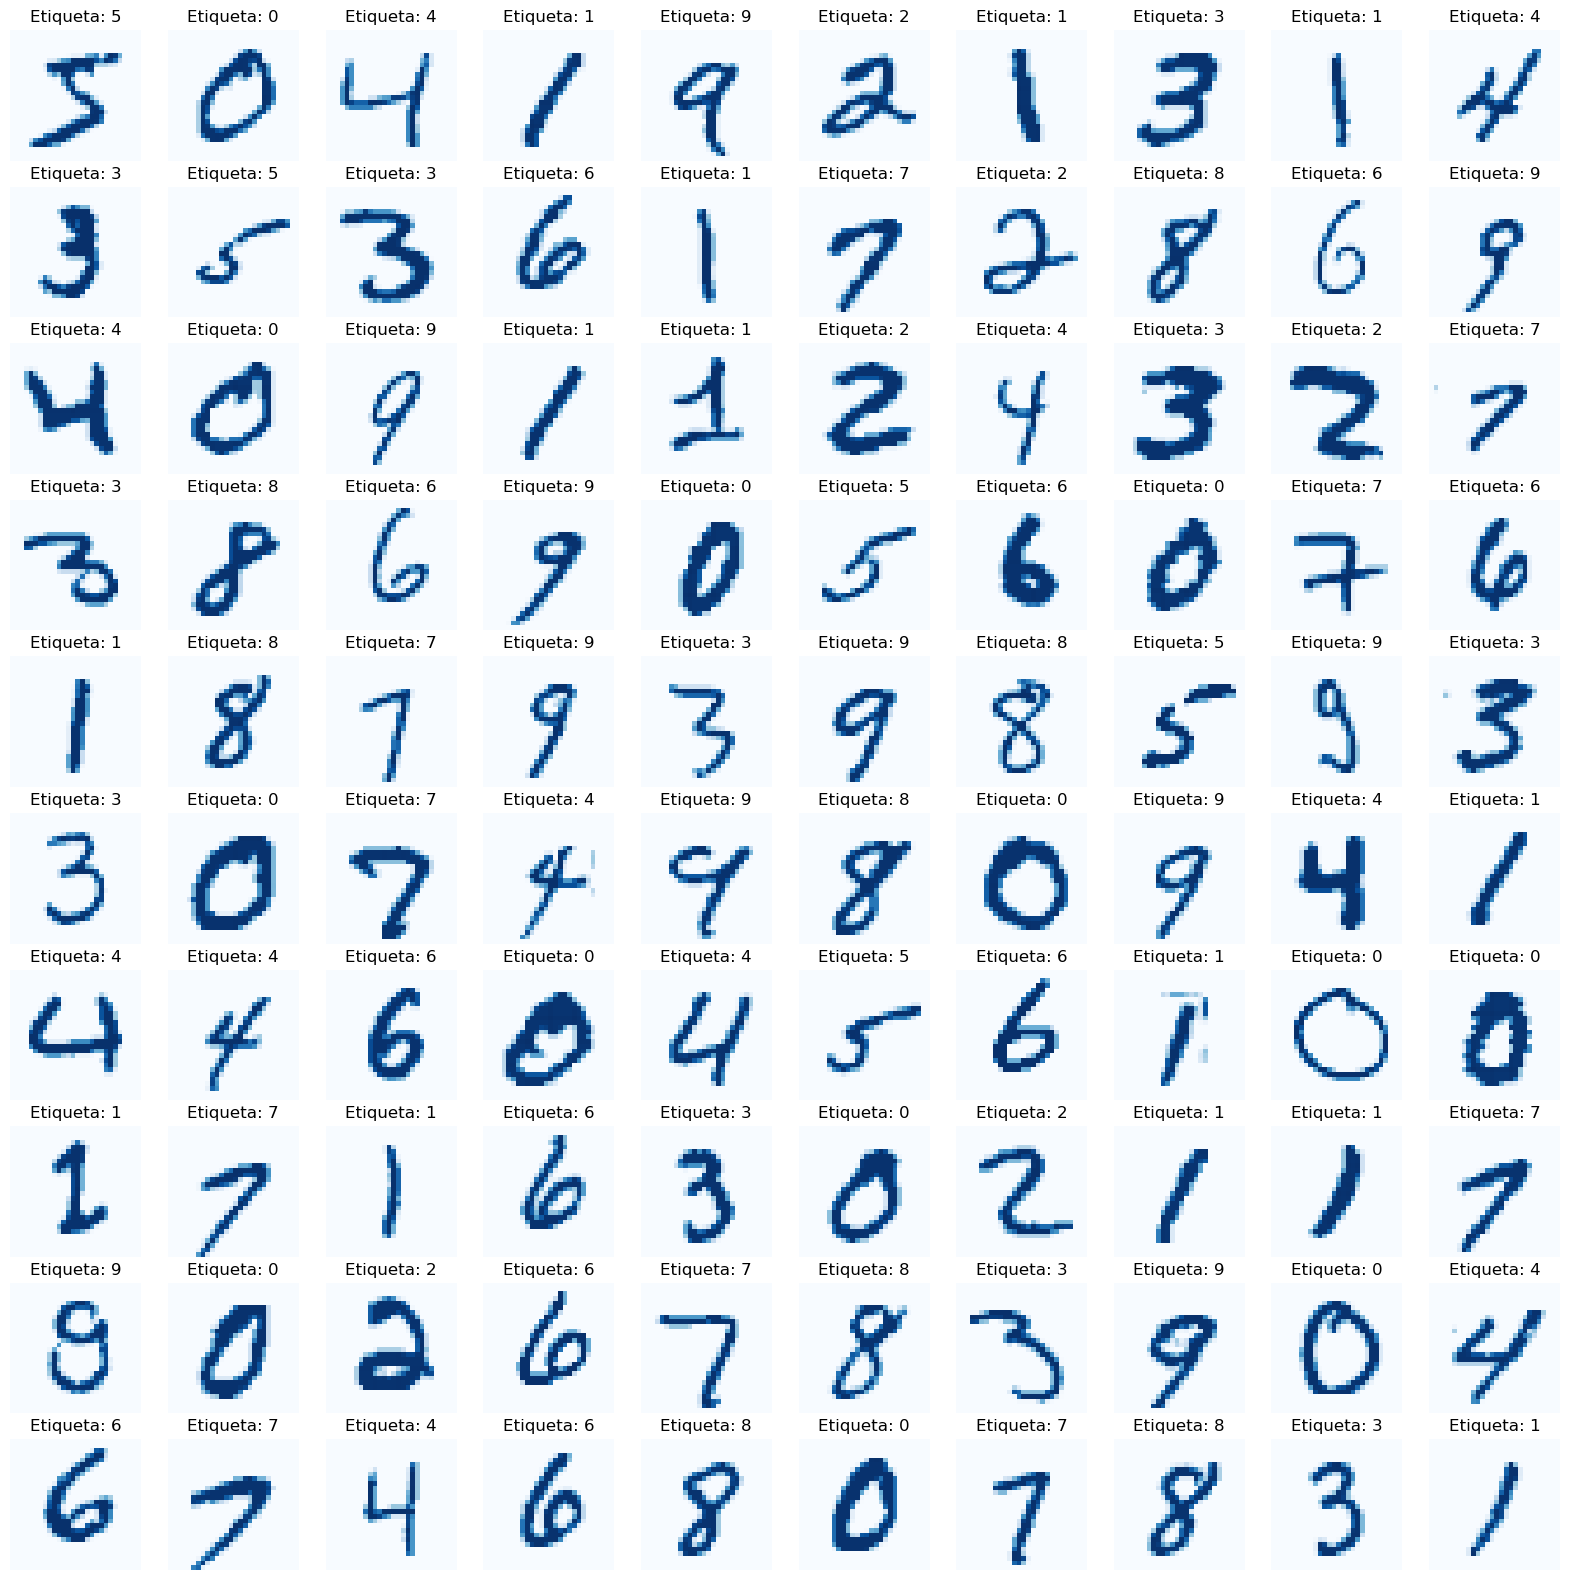

In [7]:
ncols = 10
nrows = 10

fig, axs = plt.subplots(figsize = (20, 20))
plt.axis('off')

print('Imagenes de entrenamiento\n')

for i in range(ncols * nrows):

  axs = fig.add_subplot(nrows, ncols, i + 1)
  axs.imshow(x_train[i], cmap = 'Blues')
  axs.axis('off')

  label = 'Etiqueta: ' + str(y_train[i])
  plt.title(label)

plt.show()

In [8]:
model = tf.keras.Sequential([
    #tf.keras.layers.Dense(units=1, activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(units = 10, activation = 'softmax',input_shape=(784,))])
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                7850      
                                                                 
Total params: 7,850
Trainable params: 7,850
Non-trainable params: 0
_________________________________________________________________


2026-06-04 15:57:09.164569: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [9]:
tf.keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [10]:
model.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)

In [11]:
history = model.fit(
    x_train_flat,y_train,
    epochs=20,
    validation_data=(x_test_flat,y_test)
)

Epoch 1/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.7874 - accuracy: 0.8129 - val_loss: 0.4809 - val_accuracy: 0.8790
Epoch 2/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.4583 - accuracy: 0.8807 - val_loss: 0.3998 - val_accuracy: 0.8927
Epoch 3/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.4049 - accuracy: 0.8909 - val_loss: 0.3684 - val_accuracy: 0.9000
Epoch 4/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3782 - accuracy: 0.8962 - val_loss: 0.3480 - val_accuracy: 0.9048
Epoch 5/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3612 - accuracy: 0.9001 - val_loss: 0.3352 - val_accuracy: 0.9083
Epoch 6/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3491 - accuracy: 0.9029 - val_loss: 0.3262 - val_accuracy: 0.9103
Epoch 7/20
1875/1875 [==============================] - 3s 2ms/step - loss: 0.3401 - accuracy: 0.9049 - val_loss: 0.3196 - val_accuracy:

Text(0.5, 1.0, 'LOSS')

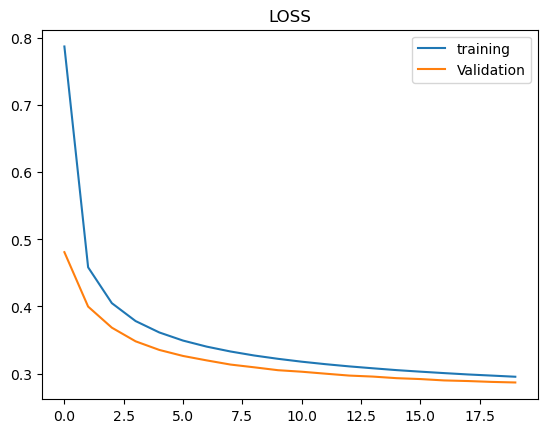

In [12]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")

In [13]:
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, activation='linear',input_shape=(784,)),
    tf.keras.layers.Dense(units = 10, activation = 'softmax')])
model_2.summary()

model_2.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_2)

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_1 (Dense)             (None, 1)                 785       
                                                                 
 dense_2 (Dense)             (None, 10)                20        
                                                                 
Total params: 805
Trainable params: 805
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [14]:
history_2 = model_2.fit(
    x_train_flat,y_train,
    epochs=20,
    validation_data=(x_test_flat,y_test)
)

Epoch 1/20
1875/1875 [==============================] - 4s 2ms/step - loss: 1.9345 - accuracy: 0.2331 - val_loss: 1.7736 - val_accuracy: 0.2760
Epoch 2/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.7138 - accuracy: 0.3051 - val_loss: 1.6833 - val_accuracy: 0.3277
Epoch 3/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6512 - accuracy: 0.3459 - val_loss: 1.6449 - val_accuracy: 0.3572
Epoch 4/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6221 - accuracy: 0.3655 - val_loss: 1.6242 - val_accuracy: 0.3757
Epoch 5/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.6062 - accuracy: 0.3760 - val_loss: 1.6130 - val_accuracy: 0.3837
Epoch 6/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.5961 - accuracy: 0.3818 - val_loss: 1.6044 - val_accuracy: 0.3865
Epoch 7/20
1875/1875 [==============================] - 3s 2ms/step - loss: 1.5895 - accuracy: 0.3881 - val_loss: 1.6019 - val_accuracy:

In [15]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=1, activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(units = 10, activation = 'softmax')])
model_3.summary()
model_3.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_3)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 1)                 785       
                                                                 
 dense_4 (Dense)             (None, 10)                20        
                                                                 
Total params: 805
Trainable params: 805
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [16]:
history_3 = model_3.fit(
    x_train_flat,y_train,
    epochs=50,
    validation_data=(x_test_flat,y_test)
)

Epoch 1/50
1875/1875 [==============================] - 3s 2ms/step - loss: 2.0608 - accuracy: 0.2046 - val_loss: 1.9146 - val_accuracy: 0.2141
Epoch 2/50
1875/1875 [==============================] - 3s 2ms/step - loss: 1.8685 - accuracy: 0.2221 - val_loss: 1.8398 - val_accuracy: 0.2223
Epoch 3/50
1875/1875 [==============================] - 3s 2ms/step - loss: 1.8202 - accuracy: 0.2252 - val_loss: 1.8126 - val_accuracy: 0.2304
Epoch 4/50
1875/1875 [==============================] - 3s 2ms/step - loss: 1.7973 - accuracy: 0.2332 - val_loss: 1.7963 - val_accuracy: 0.2320
Epoch 5/50
1875/1875 [==============================] - 3s 1ms/step - loss: 1.7814 - accuracy: 0.2431 - val_loss: 1.7850 - val_accuracy: 0.2593
Epoch 6/50
1875/1875 [==============================] - 3s 1ms/step - loss: 1.7687 - accuracy: 0.2544 - val_loss: 1.7740 - val_accuracy: 0.2661
Epoch 7/50
1875/1875 [==============================] - 3s 2ms/step - loss: 1.7581 - accuracy: 0.2649 - val_loss: 1.7661 - val_accuracy:

(-1.0, 10.0)

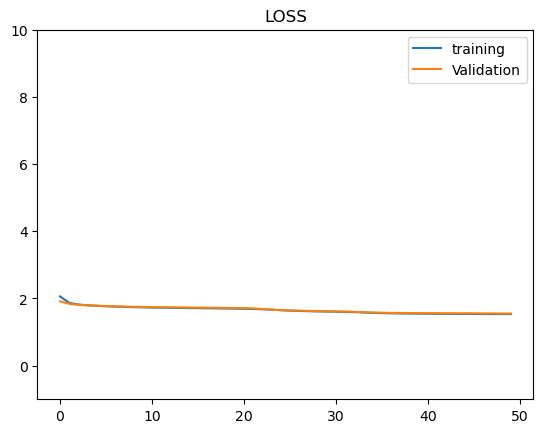

In [17]:
train_loss = history_3.history['loss']
val_loss = history_3.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")
plt.ylim(-1,10)

In [18]:
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(units=512, activation='relu',input_shape=(784,)),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 10, activation = 'softmax')])
model_5.summary()
model_5.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(model_5)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 512)               401920    
                                                                 
 dense_6 (Dense)             (None, 512)               262656    
                                                                 
 dense_7 (Dense)             (None, 10)                5130      
                                                                 
Total params: 669,706
Trainable params: 669,706
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [19]:
history_5 = model_5.fit(
    x_train_flat,y_train,
    batch_size =128,
    epochs=50,
    validation_data=(x_test_flat,y_test)
)

Epoch 1/50
469/469 [==============================] - 4s 9ms/step - loss: 1.0947 - accuracy: 0.7633 - val_loss: 0.5159 - val_accuracy: 0.8762
Epoch 2/50
469/469 [==============================] - 4s 9ms/step - loss: 0.4495 - accuracy: 0.8825 - val_loss: 0.3671 - val_accuracy: 0.8974
Epoch 3/50
469/469 [==============================] - 4s 8ms/step - loss: 0.3602 - accuracy: 0.8998 - val_loss: 0.3189 - val_accuracy: 0.9125
Epoch 4/50
469/469 [==============================] - 4s 8ms/step - loss: 0.3201 - accuracy: 0.9094 - val_loss: 0.2902 - val_accuracy: 0.9176
Epoch 5/50
469/469 [==============================] - 4s 9ms/step - loss: 0.2941 - accuracy: 0.9160 - val_loss: 0.2743 - val_accuracy: 0.9226
Epoch 6/50
469/469 [==============================] - 4s 9ms/step - loss: 0.2747 - accuracy: 0.9218 - val_loss: 0.2558 - val_accuracy: 0.9276
Epoch 7/50
469/469 [==============================] - 4s 9ms/step - loss: 0.2588 - accuracy: 0.9262 - val_loss: 0.2433 - val_accuracy: 0.9304
Epoch 

(0.0, 5.0)

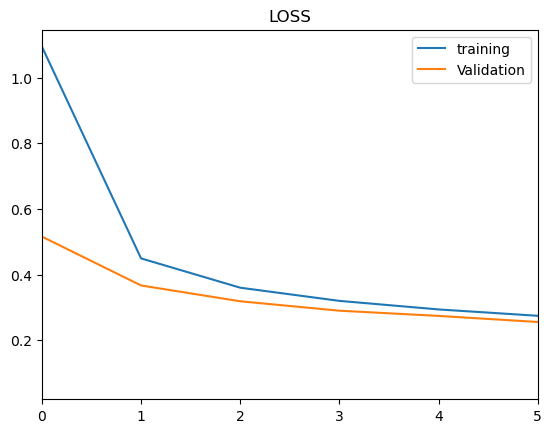

In [20]:
train_loss = history_5.history['loss']
val_loss = history_5.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")
plt.xlim(0,5)

In [21]:
print(np.shape(x_train),np.shape(x_test))
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)
print(np.shape(x_train),np.shape(x_test))

(60000, 28, 28) (10000, 28, 28)
(60000, 28, 28, 1) (10000, 28, 28, 1)


In [22]:
modelConv_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(28,28,1)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 10, activation = 'softmax')])
modelConv_1.summary()
modelConv_1.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(modelConv_1)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 13, 13, 16)        160       
                                                                 
 flatten (Flatten)           (None, 2704)              0         
                                                                 
 dense_8 (Dense)             (None, 512)               1384960   
                                                                 
 dense_9 (Dense)             (None, 10)                5130      
                                                                 
Total params: 1,390,250
Trainable params: 1,390,250
Non-trainable params: 0
_________________________________________________________________
You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [23]:
np.shape(x_test)

(10000, 28, 28, 1)

In [24]:
history_conv1 = modelConv_1 .fit(
    x_train,y_train,
    batch_size =128,
    epochs=20,
    validation_data=(x_test,y_test)
)

Epoch 1/20
469/469 [==============================] - 11s 23ms/step - loss: 0.9258 - accuracy: 0.7857 - val_loss: 0.3683 - val_accuracy: 0.9001
Epoch 2/20
469/469 [==============================] - 11s 24ms/step - loss: 0.3404 - accuracy: 0.9043 - val_loss: 0.2884 - val_accuracy: 0.9165
Epoch 3/20
469/469 [==============================] - 13s 27ms/step - loss: 0.2827 - accuracy: 0.9204 - val_loss: 0.2485 - val_accuracy: 0.9298
Epoch 4/20
469/469 [==============================] - 12s 26ms/step - loss: 0.2475 - accuracy: 0.9300 - val_loss: 0.2206 - val_accuracy: 0.9375
Epoch 5/20
469/469 [==============================] - 14s 30ms/step - loss: 0.2211 - accuracy: 0.9377 - val_loss: 0.2009 - val_accuracy: 0.9426
Epoch 6/20
469/469 [==============================] - 12s 26ms/step - loss: 0.1996 - accuracy: 0.9439 - val_loss: 0.1847 - val_accuracy: 0.9486
Epoch 7/20
469/469 [==============================] - 14s 29ms/step - loss: 0.1819 - accuracy: 0.9481 - val_loss: 0.1682 - val_accuracy:

Text(0.5, 1.0, 'LOSS')

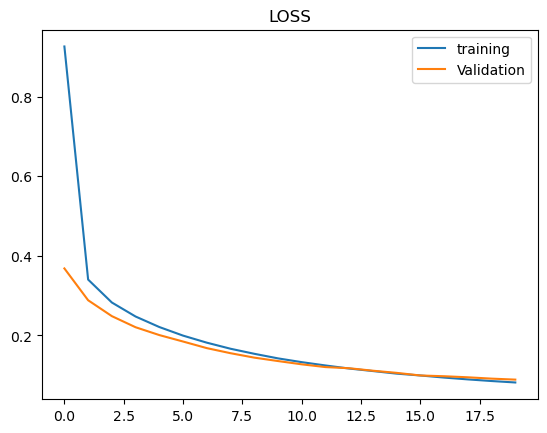

In [25]:
train_loss = history_conv1.history['loss']
val_loss = history_conv1.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")


In [26]:
modelConv_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(filters=16,kernel_size=(3,3),strides=(2,2),padding='valid',input_shape=(28,28,1)),
    tf.keras.layers.MaxPool2D(pool_size= (2,2)),
    tf.keras.layers.Conv2D(filters=32,kernel_size=(3,3),strides=(2,2),padding='valid',activation='relu'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=512, activation='relu'),
    tf.keras.layers.Dense(units = 10, activation = 'softmax')])
modelConv_2.summary()
modelConv_2.compile(
    loss = 'sparse_categorical_crossentropy', #loss function for multiple categories
    optimizer='sgd',#stochastic gradient descent
    metrics=['accuracy'] #accuracy
)
tf.keras.utils.plot_model(modelConv_2)

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_1 (Conv2D)           (None, 13, 13, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 6, 6, 16)         0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 2, 2, 32)          4640      
                                                                 
 flatten_1 (Flatten)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 512)               66048     
                                                                 
 dense_11 (Dense)            (None, 10)                5130      
                                                      

In [27]:
history_conv2 = modelConv_2 .fit(
    x_train,y_train,
    batch_size =128,
    epochs=10,
    validation_data=(x_test,y_test)
)

Epoch 1/10
469/469 [==============================] - 5s 10ms/step - loss: 2.0867 - accuracy: 0.4066 - val_loss: 1.3604 - val_accuracy: 0.7212
Epoch 2/10
469/469 [==============================] - 5s 10ms/step - loss: 0.8026 - accuracy: 0.7801 - val_loss: 0.5945 - val_accuracy: 0.8178
Epoch 3/10
469/469 [==============================] - 5s 10ms/step - loss: 0.5552 - accuracy: 0.8333 - val_loss: 0.4943 - val_accuracy: 0.8468
Epoch 4/10
469/469 [==============================] - 5s 10ms/step - loss: 0.4775 - accuracy: 0.8553 - val_loss: 0.4311 - val_accuracy: 0.8683
Epoch 5/10
469/469 [==============================] - 5s 10ms/step - loss: 0.4263 - accuracy: 0.8694 - val_loss: 0.3848 - val_accuracy: 0.8804
Epoch 6/10
469/469 [==============================] - 5s 10ms/step - loss: 0.3867 - accuracy: 0.8819 - val_loss: 0.3580 - val_accuracy: 0.8891
Epoch 7/10
469/469 [==============================] - 5s 10ms/step - loss: 0.3538 - accuracy: 0.8918 - val_loss: 0.3246 - val_accuracy: 0.8981

Text(0.5, 1.0, 'LOSS')

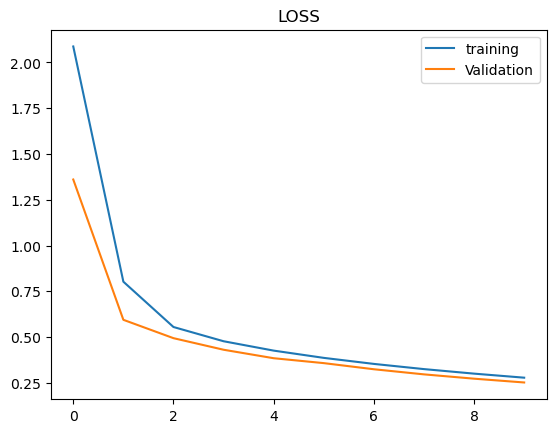

In [28]:
train_loss = history_conv2.history['loss']
val_loss = history_conv2.history['val_loss']
ite_loss= np.arange(len(train_loss))

plt.plot(ite_loss,train_loss,label='training')
plt.plot(ite_loss,val_loss,label='Validation')
plt.legend()
plt.title("LOSS")